# Лабораторная работа № 5

## Задания

![tasks](./tasks.png)

### Прямая задача

$$
\begin{aligned}
U_t &= a^2ΔU, (x, t) ∈ (0, l) × (0, T) \\
U|_{t=0} &= U_0 \\
U(0, t) &= 0 \\ 
U(l, t) &= 0
\end{aligned}
$$

### Решение прямой задачи

$$
\begin{aligned}
U(x, t) &= \sum_{n=1}^{∞}c_ne^{-λ_na^2t}\sin\frac{πnx}{l} \\
c_n &= \frac{2}{l}\int_{0}^{l}U_0(x)\sin\frac{πnx}{l}dx \\
λ_n &= \frac{π^2n^2}{l^2}
\end{aligned}
$$

### Обратная задача

Зная $U_T$, найти $U_0$

Коэффициенты Фурье функции $U_T$ равны:

$$
d_n = c_ne^{-λ_na^2T}
$$

Тогда $c_n$ можно найти:

$$
c_n = d_ne^{λ_na^2T}
$$

Однако такое преобразование неустойчиво, потому применяем регуляризацию Тихонова:

$$
c_n(α) = d_n\frac{e^{λ_na^2T}}{1 + αe^{2λ_na^2T}}
$$

Но и здесь возникает проблема. Просто прописать это выражение нельзя в Python, ибо в таком случае придётся посчитать значения экспонент, что приведёт к переполнению памяти. Поэтому, целесообразно будет это выражение просто сократить на $e^{2λ_na^2T}$ и тогда:

$$
c_n(α) = d_n\frac{e^{-λ_na^2T}}{e^{-2λ_na^2T} + α}
$$

$α$ - параметр регуляризации

### Дискретное преобразование синусов (DST)

$$
X_k = \sum_{n=1}^{N}x_n\sin\frac{πkn}{N+1}, k ∈ [1, N]
$$

### Обратное дискретное преобразование синусов (IDST)

$$
x_n = \frac{2}{N+1}\sum_{k=1}^{N}X_k\sin\frac{πkn}{N+1}
$$

## Реализация

### Библиотеки

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Разностная схема (явная)

$$
\frac{U_i^{j+1} - U_i^j}{τ} = a^2\frac{U_{i+1}^j - 2U_i^j + U_{i-1}^j}{h^2}
$$

$τ$ - разбиение по $t ∈ (0, T)$, $j$ - индекс

$h$ - разбиение по $x ∈ (0, l)$, $i$ - индекс

### Условие Куранта

$$
a^2τ < \frac{h^2}{2}
$$

### Входные параметры

In [2]:
a = 1
T = 1
l = 10
dimx = 1000  # количество точек по x

def U0(x):
    if 1 <= x <= 4:
        return 1

    if 6 <= x <= 9:
        return 2

    return 0

In [3]:
x = np.linspace(0, l, dimx, endpoint=True)
h = x[1] - x[0]

tau = 0.9 * h**2 / (2 * a**2)
dimt = int(T/tau) + 1

### Нахождение решения через разностную схему

In [4]:
U = np.zeros((dimt, dimx), dtype=np.float64)

coef = a**2 * tau / h**2

for j in range(dimt):
    for i in range(1, dimx-1):
        if j == 0:
            U[j][i] = U0(x[i])
            
        else:
            U[j][i] = U[j-1][i] + coef*(U[j-1][i+1] - 2*U[j-1][i] + U[j-1][i-1])

### DST

In [5]:
U_T = U[-1, :]

d = np.zeros(dimx, dtype=np.float64)

for k in range(dimx):
    for n in range(dimx):
        d[k] += U_T[n] * np.sin(np.pi*k*n / (dimx + 1)) 

## Фильтрация

In [27]:
reg_values = np.linspace(0.0001, 0.01, 5, endpoint=True)

c = np.zeros((reg_values.shape[0], dimx), dtype=np.float64)

for alpha in range(reg_values.shape[0]):
    for n in range(dimx):
        exp_val = np.exp(-np.pi**2 * n**2 * a**2 * T / l**2)

        c[alpha][n] = d[n] * exp_val / (exp_val**2 + reg_values[alpha])

### IDST

In [28]:
U0_recon = np.zeros((reg_values.shape[0], dimx), dtype=np.float64)

for alpha in range(reg_values.shape[0]):
    for k in range(dimx):
        for n in range(dimx):
            U0_recon[alpha][k] += 2 / (dimx + 1) * c[alpha][n] * np.sin(np.pi*k*n / (dimx + 1))

### Отрисовка графиков

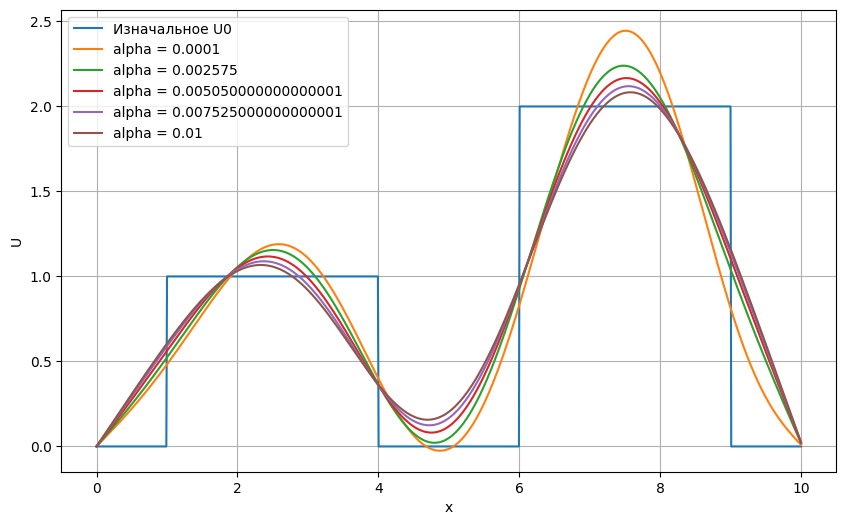

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(x, U[0, :], label="Изначальное U0")

for alpha in range(reg_values.shape[0]):
    plt.plot(x, U0_recon[alpha], label=f"alpha = {reg_values[alpha]}")

plt.xlabel("x")
plt.ylabel("U")

plt.legend()
plt.grid()
plt.show()